# Experiment 6: Outlier Detection using Isolation Forest

### Aim:
To detect anomalous (fraudulent) transactions using an unsupervised anomaly detection technique.

### Objective:
To apply a density/distance-based outlier detection method and evaluate how well it identifies fraudulent transactions.

### Theory:
Outlier detection identifies rare observations that significantly differ from the majority of the data.

Isolation Forest is an unsupervised anomaly detection algorithm that works by randomly partitioning data. 
Anomalies are easier to isolate and therefore require fewer splits.

Unlike classification models, anomaly detection does not require labeled data during training.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
df = pd.read_csv("data/online_fraud.csv")

# Sample for faster processing
df = df.sample(n=100000, random_state=42)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (100000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


In [3]:
# Drop ID columns
df = df.drop(['nameOrig', 'nameDest'], axis=1)

# Convert categorical variable
df = pd.get_dummies(df, columns=['type'], drop_first=True)


Isolation Forest is UNSUPERVISED
We will train using only X (ignore y during training)

In [4]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [6]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,   # assume ~1% anomalies
    random_state=42
)

iso_forest.fit(X_scaled)


IsolationForest(contamination=0.01, random_state=42)

In [7]:
y_pred = iso_forest.predict(X_scaled)

# Convert to 0 (normal) and 1 (fraud-like anomaly)
y_pred = np.where(y_pred == -1, 1, 0)


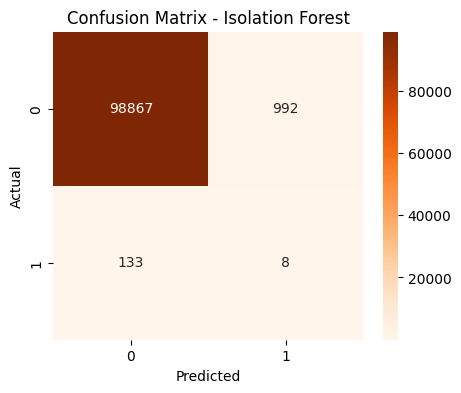

In [8]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Isolation Forest")
plt.show()


In [9]:
print(classification_report(y, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99     99859
           1       0.01      0.06      0.01       141

    accuracy                           0.99    100000
   macro avg       0.50      0.52      0.50    100000
weighted avg       1.00      0.99      0.99    100000



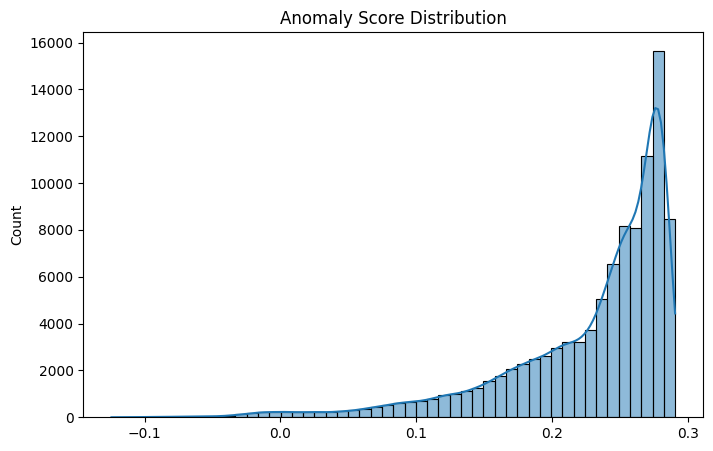

In [10]:
scores = iso_forest.decision_function(X_scaled)

plt.figure(figsize=(8,5))
sns.histplot(scores, bins=50, kde=True)
plt.title("Anomaly Score Distribution")
plt.show()


## DBSCAN for Density-Based Outlier Detection

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups dense regions together and marks sparse points as noise (outliers).

Points labeled as -1 are considered anomalies.


In [11]:
from sklearn.cluster import DBSCAN


In [12]:
dbscan = DBSCAN(
    eps=0.8,       # radius parameter (you may tune)
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)


In [13]:
dbscan_pred = np.where(dbscan_labels == -1, 1, 0)


In [14]:
print("Number of DBSCAN Outliers:", sum(dbscan_pred))


Number of DBSCAN Outliers: 855


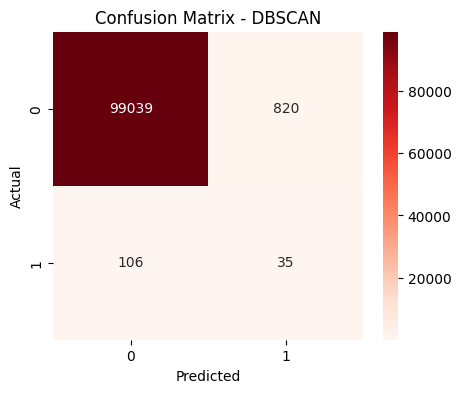

In [15]:
cm_db = confusion_matrix(y, dbscan_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_db, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DBSCAN")
plt.show()


In [16]:
print(classification_report(y, dbscan_pred))


              precision    recall  f1-score   support

           0       1.00      0.99      1.00     99859
           1       0.04      0.25      0.07       141

    accuracy                           0.99    100000
   macro avg       0.52      0.62      0.53    100000
weighted avg       1.00      0.99      0.99    100000



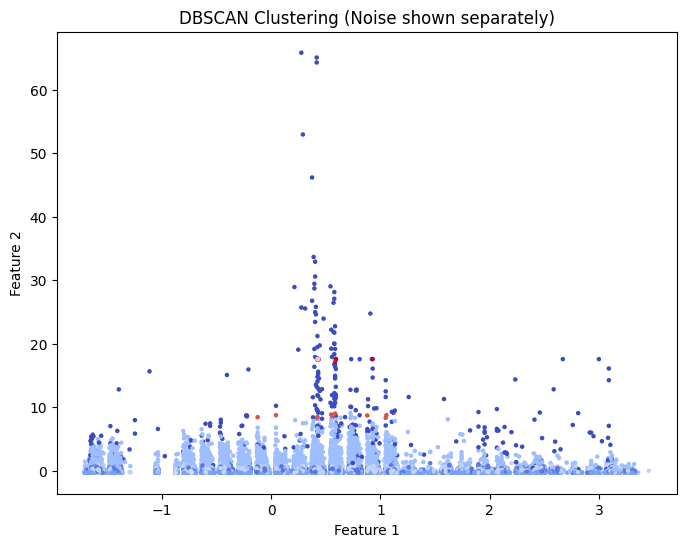

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 0],   # first feature
    X_scaled[:, 1],   # second feature
    c=dbscan_labels,
    cmap='coolwarm',
    s=5
)

plt.title("DBSCAN Clustering (Noise shown separately)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


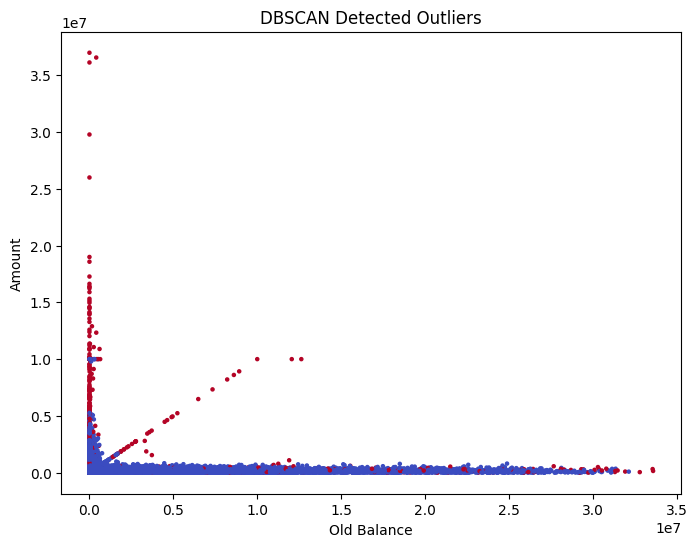

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['oldbalanceOrg'],
    df['amount'],
    c=dbscan_pred,
    cmap='coolwarm',
    s=5
)

plt.title("DBSCAN Detected Outliers")
plt.xlabel("Old Balance")
plt.ylabel("Amount")
plt.show()


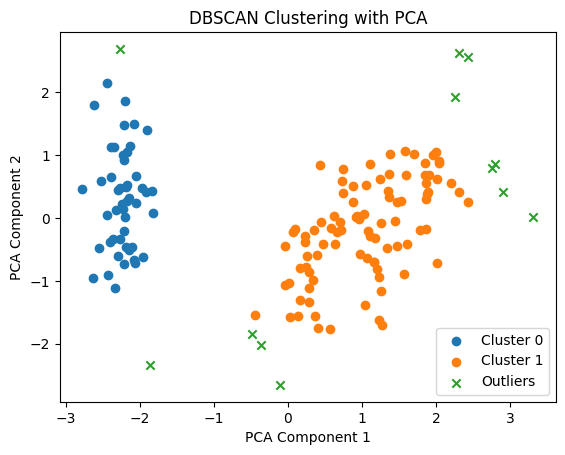

In [19]:
# exp6_dbscan_pca.py

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# Step 1: Load Dataset
data = load_iris()
X = data.data

# Step 2: Feature Scaling (Very Important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA (Reduce to 2D for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_pca)

# Step 5: Identify unique clusters
unique_labels = set(labels)

# Step 6: Plotting
plt.figure()

for label in unique_labels:
    if label == -1:
        # Outliers in red
        plt.scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            marker='x',
            label='Outliers'
        )
    else:
        plt.scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            label=f'Cluster {label}'
        )

plt.title("DBSCAN Clustering with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


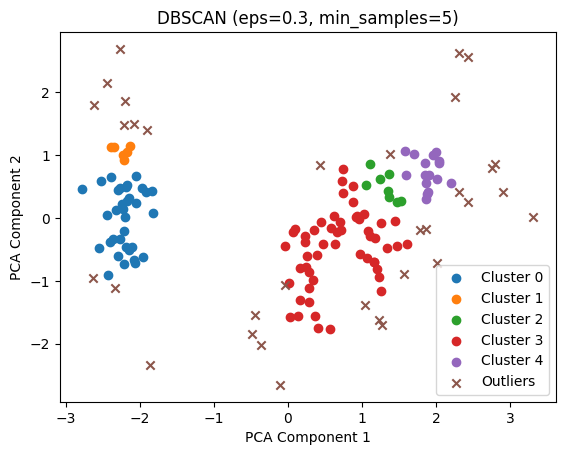

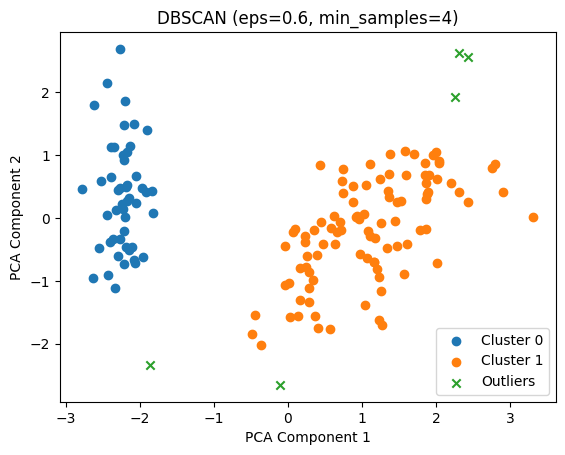

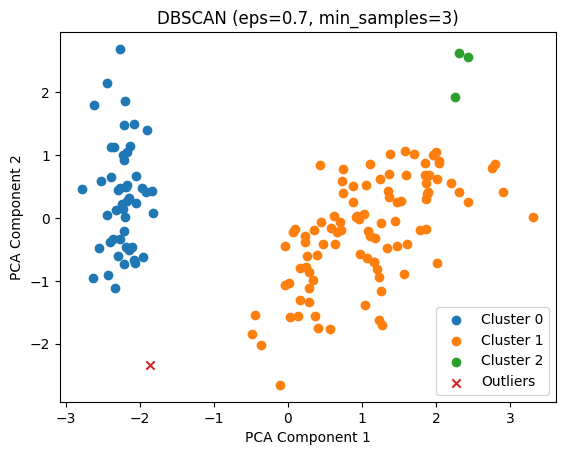

In [20]:
# exp6_dbscan_pca_loop.py

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# Step 1: Load Dataset
data = load_iris()
X = data.data

# Step 2: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA (2D for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Parameter combinations
params = [
    (0.3, 5),
    (0.6, 4),
    (0.7, 3)
]

# Step 5: Loop through parameters
for eps, min_samples in params:

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_pca)

    unique_labels = set(labels)

    plt.figure()

    for label in unique_labels:
        if label == -1:
            # Outliers
            plt.scatter(
                X_pca[labels == label, 0],
                X_pca[labels == label, 1],
                marker='x',
                label='Outliers'
            )
        else:
            plt.scatter(
                X_pca[labels == label, 0],
                X_pca[labels == label, 1],
                label=f'Cluster {label}'
            )

    plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples})")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.show()


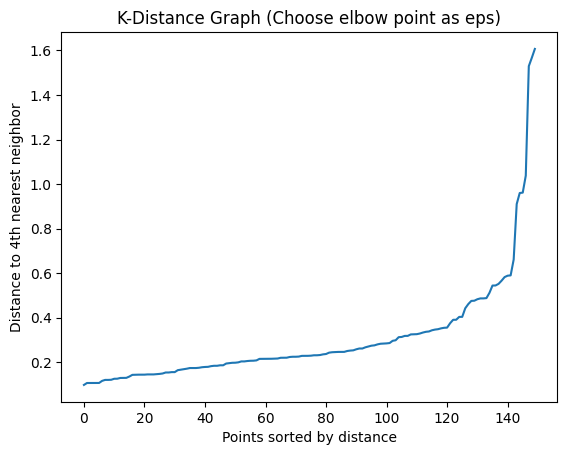

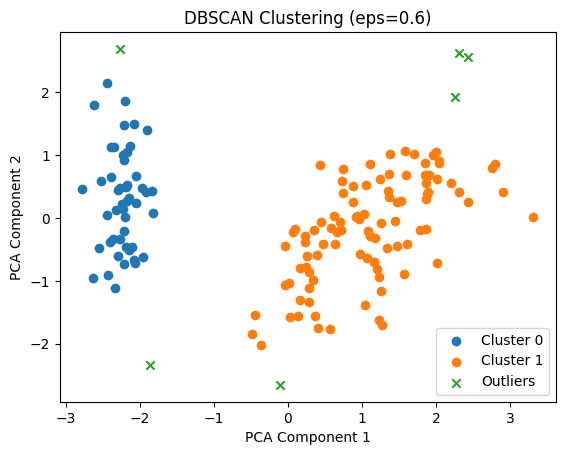

In [21]:
# exp6_dbscan_auto_eps.py

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Step 1: Load Dataset
data = load_iris()
X = data.data

# Step 2: Scale Features (Important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA (2D for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ---------------------------------------------------
# Step 4: K-Distance Graph (Automatic eps selection)
# ---------------------------------------------------

k = 4   # Usually min_samples - 1
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Take the farthest neighbor distance
k_distances = distances[:, -1]

# Sort distances
k_distances = np.sort(k_distances)

plt.figure()
plt.plot(k_distances)
plt.title("K-Distance Graph (Choose elbow point as eps)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 4th nearest neighbor")
plt.show()

# ---------------------------------------------------
# Step 5: Choose eps from graph
# (You visually inspect elbow and set eps manually)
# ---------------------------------------------------

eps_value = 0.6   # <-- Adjust based on elbow in graph
min_samples = 5

# Step 6: Apply DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
labels = dbscan.fit_predict(X_pca)

# Step 7: Plot Clusters
unique_labels = set(labels)

plt.figure()

for label in unique_labels:
    if label == -1:
        plt.scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            marker='x',
            label='Outliers'
        )
    else:
        plt.scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            label=f'Cluster {label}'
        )

plt.title(f"DBSCAN Clustering (eps={eps_value})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()
